In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from collections import Counter
import warnings
import re
warnings.filterwarnings("ignore")

In [22]:
df = pd.read_csv("nyt_headlines_2024_2025.csv")

In [23]:
df.sample

<bound method NDFrame.sample of                                                 headline        date  month  \
0      PGA Tour and Saudi-Backed LIV Extend Deadline ...  2024-01-01      1   
1                                   Something to Whistle  2024-01-01      1   
2      U.S. Helicopters Sink 3 Houthi Boats in Red Se...  2024-01-01      1   
3      In Times Square, Hundreds of Thousands Ring In...  2024-01-01      1   
4      Quotation of the Day: In a Jewish-Arab School,...  2024-01-01      1   
...                                                  ...         ...    ...   
96505  In Chief Justice’s Annual Report, a History Le...  2025-12-31     12   
96506  Mamdani Names Top Deputies for Child Care, Ope...  2025-12-31     12   
96507                       53 Fascinating Facts of 2025  2025-12-31     12   
96508  On His Last Day, Adams Drops From View but Sti...  2025-12-31     12   
96509        Welcome to the 5-Day Brain Health Challenge  2026-01-05      1   

                  s

In [24]:
df.shape

(96510, 8)

In [25]:
df.describe()

,month,year
count,96510.000000,96510.000000
mean,6.452212,2024.495431
std,3.443914,0.499982
min,1.000000,2024.000000
25%,3.000000,2024.000000
50%,6.000000,2024.000000
75%,10.000000,2025.000000
max,12.000000,2025.000000


In [26]:
def clean_headline(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [27]:
df["clean_headline"] = df["headline"].apply(clean_headline)

In [28]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
all_stopwords = list(ENGLISH_STOP_WORDS)

In [29]:
sections_to_remove = [
    "Crosswords & Games",
    "News Briefings", 
    "Corrections",
    "Summaries",
    "Word of the Day",
    "Recipe"
]

In [30]:
df.shape

(96510, 9)

In [31]:
print(f"Total articles:  {len(df):,}")
print(f"Date range:      {df['date'].min()} → {df['date'].max()}")
print(f"Years:           {sorted(df['year'].unique())}")
print(f"Unique sections: {df['section'].nunique()}")
print(f"Missing values:\n{df.isnull().sum()}")

Total articles:  96,510
Date range:      0001-01-01 → 2026-01-05
Years:           [2024, 2025]
Unique sections: 54
Missing values:
headline            14
date                 0
month                0
section             17
author            5743
url                 13
abstract          1459
year                 0
clean_headline       0
dtype: int64


In [32]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df[df["date"].dt.year.isin([2024, 2025])]
df = df[df["date"] <= "2025-12-31"]

In [33]:
df = df.dropna(subset=["headline", "url"])
print(f"After dropping nulls:   {len(df):,}")

After dropping nulls:   96,495


In [34]:
df["section"] = df["section"].fillna("Unknown")
df["author"]  = df["author"].fillna("Unknown")
df["abstract"] = df["abstract"].fillna("")

In [35]:
sections_to_remove = [
    "Crosswords & Games",
    "News Briefings",
    "Corrections",
    "Summaries",
    "Word of the Day",
    "Recipes"
]
df = df[~df["section"].isin(sections_to_remove)]
print(f"After section cleanup:  {len(df):,}")

After section cleanup:  93,547


In [36]:
df = df.drop_duplicates(subset=["headline"])
print(f"After deduplication:    {len(df):,}")

After deduplication:    91,547


In [37]:
df = df.reset_index(drop=True)

In [38]:
df.shape

(91547, 9)

In [39]:
df = pd.read_csv("nyt_headlines_2024_2025_clean.csv")
print(f"Loaded {len(df)} headlines")
print(df["headline"].head())

Loaded 91547 headlines
0    PGA Tour and Saudi-Backed LIV Extend Deadline ...
1    U.S. Helicopters Sink 3 Houthi Boats in Red Se...
2    In Times Square, Hundreds of Thousands Ring In...
3    Half of Gazans Are at Risk of Starving, U.N. W...
4    How to Start the New Year? Keep the Sea Goddes...
Name: headline, dtype: object


In [40]:
df.sample()

,headline,date,month,section,author,url,abstract,year,clean_headline
48502,Evacuation Orders Given Late to Area Where Fir...,2025-01-22,1,U.S.,By Claire Fahy,https://www.nytimes.com/2025/01/22/us/evacuati...,All 17 people who died in the Eaton fire lived...,2025,evacuation orders given late to area where fir...


In [41]:
df.describe()

,month,year
count,91547.000000,91547.000000
mean,6.451539,2024.500956
std,3.444311,0.500002
min,1.000000,2024.000000
25%,3.000000,2024.000000
50%,6.000000,2025.000000
75%,10.000000,2025.000000
max,12.000000,2025.000000


In [42]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)
X_tfidf = vectorizer.fit_transform(df["headline"])

In [43]:
svd = TruncatedSVD(n_components=100, random_state=42)
normalizer = Normalizer(copy=False)
X = normalizer.fit_transform(svd.fit_transform(X_tfidf))

print(f"Matrix shape after reduction: {X.shape}")

Matrix shape after reduction: (91547, 100)


  File "/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/joblib/externals/loky/backend/context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


k=2, inertia=83204.12
k=3, inertia=81575.03
k=4, inertia=79437.22
k=5, inertia=78198.93
k=6, inertia=76421.10
k=7, inertia=75812.31
k=8, inertia=74275.56
k=9, inertia=73940.37
k=10, inertia=72908.28
k=11, inertia=71901.20
k=12, inertia=71266.67
k=13, inertia=70612.47
k=14, inertia=69781.16
k=15, inertia=69181.61
k=16, inertia=68489.00
k=17, inertia=68109.11
k=18, inertia=67239.20
k=19, inertia=66746.10


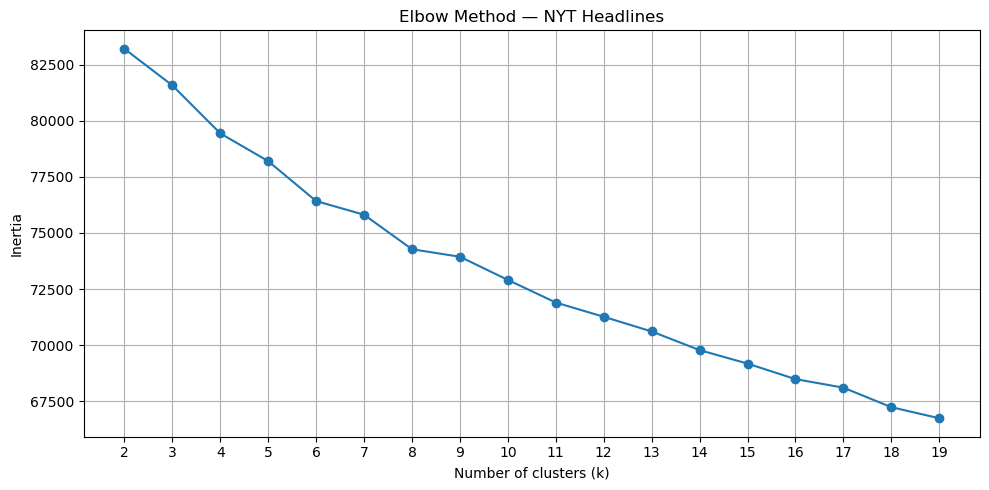

In [44]:
k_range = range(2, 20)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)
    print(f"k={k}, inertia={km.inertia_:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method — NYT Headlines")
plt.xticks(list(k_range))
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
k = 7

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X)

In [50]:
print("\n── Top words per cluster ──")
terms = vectorizer.get_feature_names_out()
for i in range(k):
    center = svd.inverse_transform(kmeans.cluster_centers_[i].reshape(1, -1))
    top_words = [terms[j] for j in center[0].argsort()[-10:][::-1]]
    print(f"\nCluster {i}: {', '.join(top_words)}")


── Top words per cluster ──

Cluster 0: israel, gaza, ukraine, israeli, russia, military, strikes, iran, killed, attack

Cluster 1: help, political, star, trial, health, law, takes, long, dead, government

Cluster 2: dies, review, wordle, star, 86, 88, 91, 87, 90, 92

Cluster 3: trump, administration, donald, tariffs, says, biden, harris, trial, judge, case

Cluster 4: biden, says, house, years, china, know, day, man, love, world

Cluster 5: new, york, jersey, trump, city, songs, era, orleans, yorkers, hampshire

Cluster 6: election, results, district, congressional, primary, presidential, senate, 2024, california, polls


In [51]:
print("\n── Sample headlines per cluster ──")
for i in range(k):
    samples = df[df["cluster"] == i]["headline"].sample(3, random_state=42).tolist()
    print(f"\nCluster {i}:")
    for h in samples:
        print(f"  • {h}")


── Sample headlines per cluster ──

Cluster 0:
  • Steve Buscemi Is Punched in Random Manhattan Attack
  • Johnson Says House Will Vote on Stalled Aid to Israel and Ukraine
  • Carnage and Contradiction: Examining a Deadly Strike in Rafah

Cluster 1:
  • Here Are Three Possible Contenders to Succeed Justin Trudeau
  • Is Pilates Political?
  • The Mystery Behind Zosia Mamet’s Ring

Cluster 2:
  • ‘Days of Wine and Roses’ Review: Romance on the Rocks
  • Review: Even With Olga Smirnova, Dutch National Ballet Falters
  • How an Artist Became the Queen of Baltimore

Cluster 3:
  • Late Night Tries to Decipher Another Rambling Trump Speech
  • Trump’s Extraordinarily Negative TV Ads
  • Zelensky Asks Trump to Attend Peace Talks, but Putin’s Plans Remain Unclear

Cluster 4:
  • Subway Train Derails in Brooklyn in 2nd Such Episode in a Week
  • Tropical Cyclone Zelia Makes Landfall in Northwest Australia
  • Oct. 7 Anniversary Arrives During Heated Final Stretch of Mayor’s Race

Cluster 5:


In [52]:
pca = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(X)

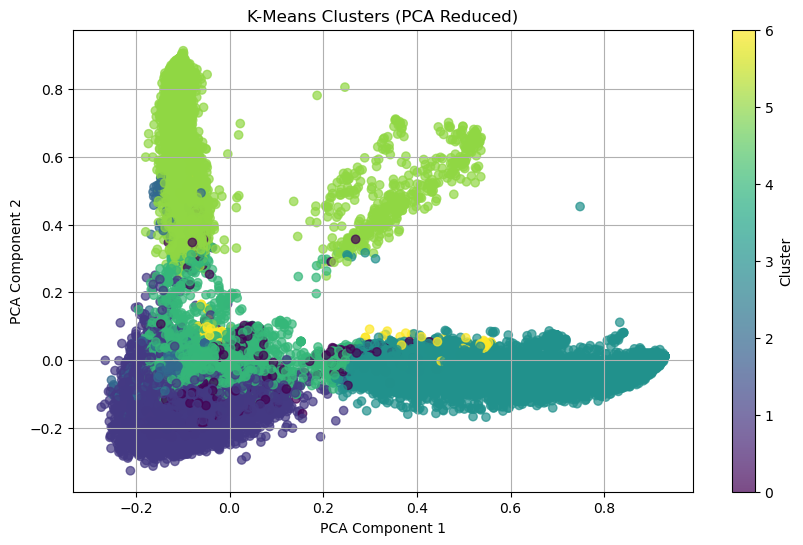

In [53]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1], 
                      c=kmeans.labels_, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.title('K-Means Clusters (PCA Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.savefig("nyt_clusters.png", dpi=300, bbox_inches="tight")  # ← same cell
plt.show()

In [54]:
plt.savefig("nyt_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [55]:
df["pca_x"] = df_pca[:, 0]
df["pca_y"] = df_pca[:, 1]

In [56]:
df["date"] = pd.to_datetime(df["date"])

In [57]:
!pip install vaderSentiment

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [58]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [59]:
print(f"Loaded {len(df)} headlines")
print(df.columns.tolist())
print(df.head())

Loaded 91547 headlines
['headline', 'date', 'month', 'section', 'author', 'url', 'abstract', 'year', 'clean_headline', 'cluster', 'pca_x', 'pca_y']
                                            headline       date  month  \
0  PGA Tour and Saudi-Backed LIV Extend Deadline ... 2024-01-01      1   
1  U.S. Helicopters Sink 3 Houthi Boats in Red Se... 2024-01-01      1   
2  In Times Square, Hundreds of Thousands Ring In... 2024-01-01      1   
3  Half of Gazans Are at Risk of Starving, U.N. W... 2024-01-01      1   
4  How to Start the New Year? Keep the Sea Goddes... 2024-01-01      1   

        section                                             author  \
0  Business Day                                   By Lauren Hirsch   
1         World  By David E. Sanger, Eric Schmitt and Vivek Sha...   
2      New York     By Andy Newman, Camille Baker and Sean Piccoli   
3         World      By Liam Stack, Gaya Gupta and Abu Bakr Bashir   
4         World                    By Jack Nicas and Dado

In [60]:
df["sentiment_score"] = df["headline"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

In [61]:
def label_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment_label"] = df["sentiment_score"].apply(label_sentiment)

In [62]:
print(df["sentiment_label"].value_counts())
print(f"\nAverage sentiment score: {df['sentiment_score'].mean():.3f}")

sentiment_label
Neutral     41308
Negative    28415
Positive    21824
Name: count, dtype: int64

Average sentiment score: -0.041


In [63]:
print(df.columns.tolist())

['headline', 'date', 'month', 'section', 'author', 'url', 'abstract', 'year', 'clean_headline', 'cluster', 'pca_x', 'pca_y', 'sentiment_score', 'sentiment_label']


In [64]:
cluster_labels = {
    0: "World News & Conflict",
    1: "Lifestyle & Culture",
    2: "Arts & Reviews",
    3: "Trump & Politics",
    4: "Breaking News & Disasters",
    5: "Business & Tech",
    6: "Election Results"
}

df["cluster_label"] = df["cluster"].map(cluster_labels)

print(df["sentiment_label"].value_counts())
print("\n── Sentiment by cluster ──")
print(df.groupby("cluster_label")["sentiment_score"].mean().sort_values())

df.to_csv("nyt_clusters_sentiment.csv", index=False)

sentiment_label
Neutral     41308
Negative    28415
Positive    21824
Name: count, dtype: int64

── Sentiment by cluster ──
cluster_label
World News & Conflict       -0.234537
Trump & Politics            -0.066286
Lifestyle & Culture         -0.038905
Business & Tech             -0.019890
Breaking News & Disasters   -0.013938
Election Results             0.004587
Arts & Reviews               0.009326
Name: sentiment_score, dtype: float64


In [65]:
#Cluster and abstract for sentiment analysis

In [66]:
df["text_combined"] = df["headline"] + " " + df["abstract"].fillna("")

In [67]:
df["sentiment_score"] = df["text_combined"].apply(
    lambda x: analyzer.polarity_scores(x)["compound"]
)

df["sentiment_label"] = df["sentiment_score"].apply(label_sentiment)

print(df["sentiment_label"].value_counts())
print(df.groupby("cluster_label")["sentiment_score"].mean().sort_values())

sentiment_label
Negative    38101
Positive    37984
Neutral     15462
Name: count, dtype: int64
cluster_label
World News & Conflict       -0.360906
Trump & Politics            -0.073183
Lifestyle & Culture         -0.004704
Breaking News & Disasters    0.020628
Election Results             0.023205
Business & Tech              0.024910
Arts & Reviews               0.097663
Name: sentiment_score, dtype: float64


In [ ]:
# graph with both headline and abstract sentiment

In [72]:
df["date"] = pd.to_datetime(df["date"])

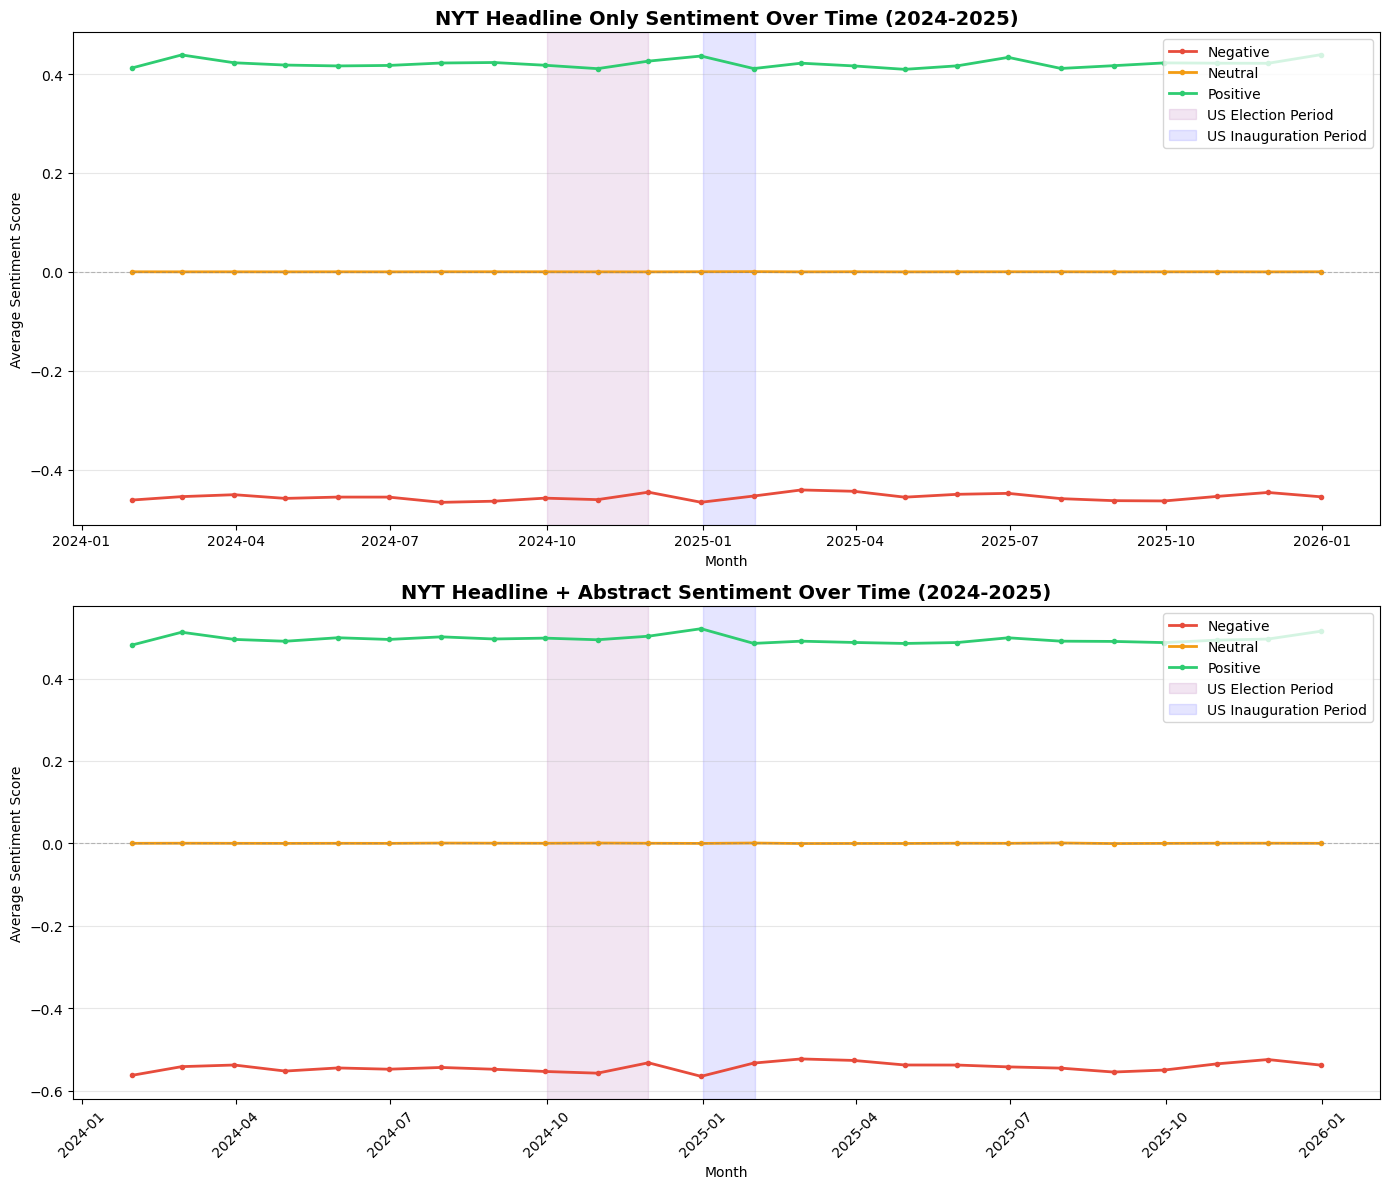

In [73]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
colours = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#f39c12'}

def add_event_lines(ax):
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvspan(pd.Timestamp('2024-10-01'), pd.Timestamp('2024-11-30'),
               alpha=0.1, color='purple', label='US Election Period')
    ax.axvspan(pd.Timestamp('2025-01-01'), pd.Timestamp('2025-02-01'),
               alpha=0.1, color='blue', label='US Inauguration Period')
    ax.grid(axis='y', alpha=0.3)
    ax.legend()
    ax.set_xlabel('Month')
    ax.set_ylabel('Average Sentiment Score')

monthly_headline = df.groupby([pd.Grouper(key='date', freq='ME'), 'sentiment_label_headline'])[
    'sentiment_score_headline'].mean().reset_index()
monthly_headline.columns = ['month_period', 'sentiment_label', 'sentiment_score']

for label, group in monthly_headline.groupby('sentiment_label'):
    ax1.plot(group['month_period'], group['sentiment_score'],
             label=label, color=colours.get(label, 'gray'),
             linewidth=2, marker='o', markersize=3)

add_event_lines(ax1)
ax1.set_title('NYT Headline Only Sentiment Over Time (2024-2025)',
              fontsize=14, fontweight='bold')

monthly_combined = df.groupby([pd.Grouper(key='date', freq='ME'), 'sentiment_label_combined'])[
    'sentiment_score_combined'].mean().reset_index()
monthly_combined.columns = ['month_period', 'sentiment_label', 'sentiment_score']

for label, group in monthly_combined.groupby('sentiment_label'):
    ax2.plot(group['month_period'], group['sentiment_score'],
             label=label, color=colours.get(label, 'gray'),
             linewidth=2, marker='o', markersize=3)

add_event_lines(ax2)
ax2.set_title('NYT Headline + Abstract Sentiment Over Time (2024-2025)',
              fontsize=14, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sentiment_comparison_over_time.png', dpi=150)
plt.show()

In [75]:
#Headline sentiment for each cluster

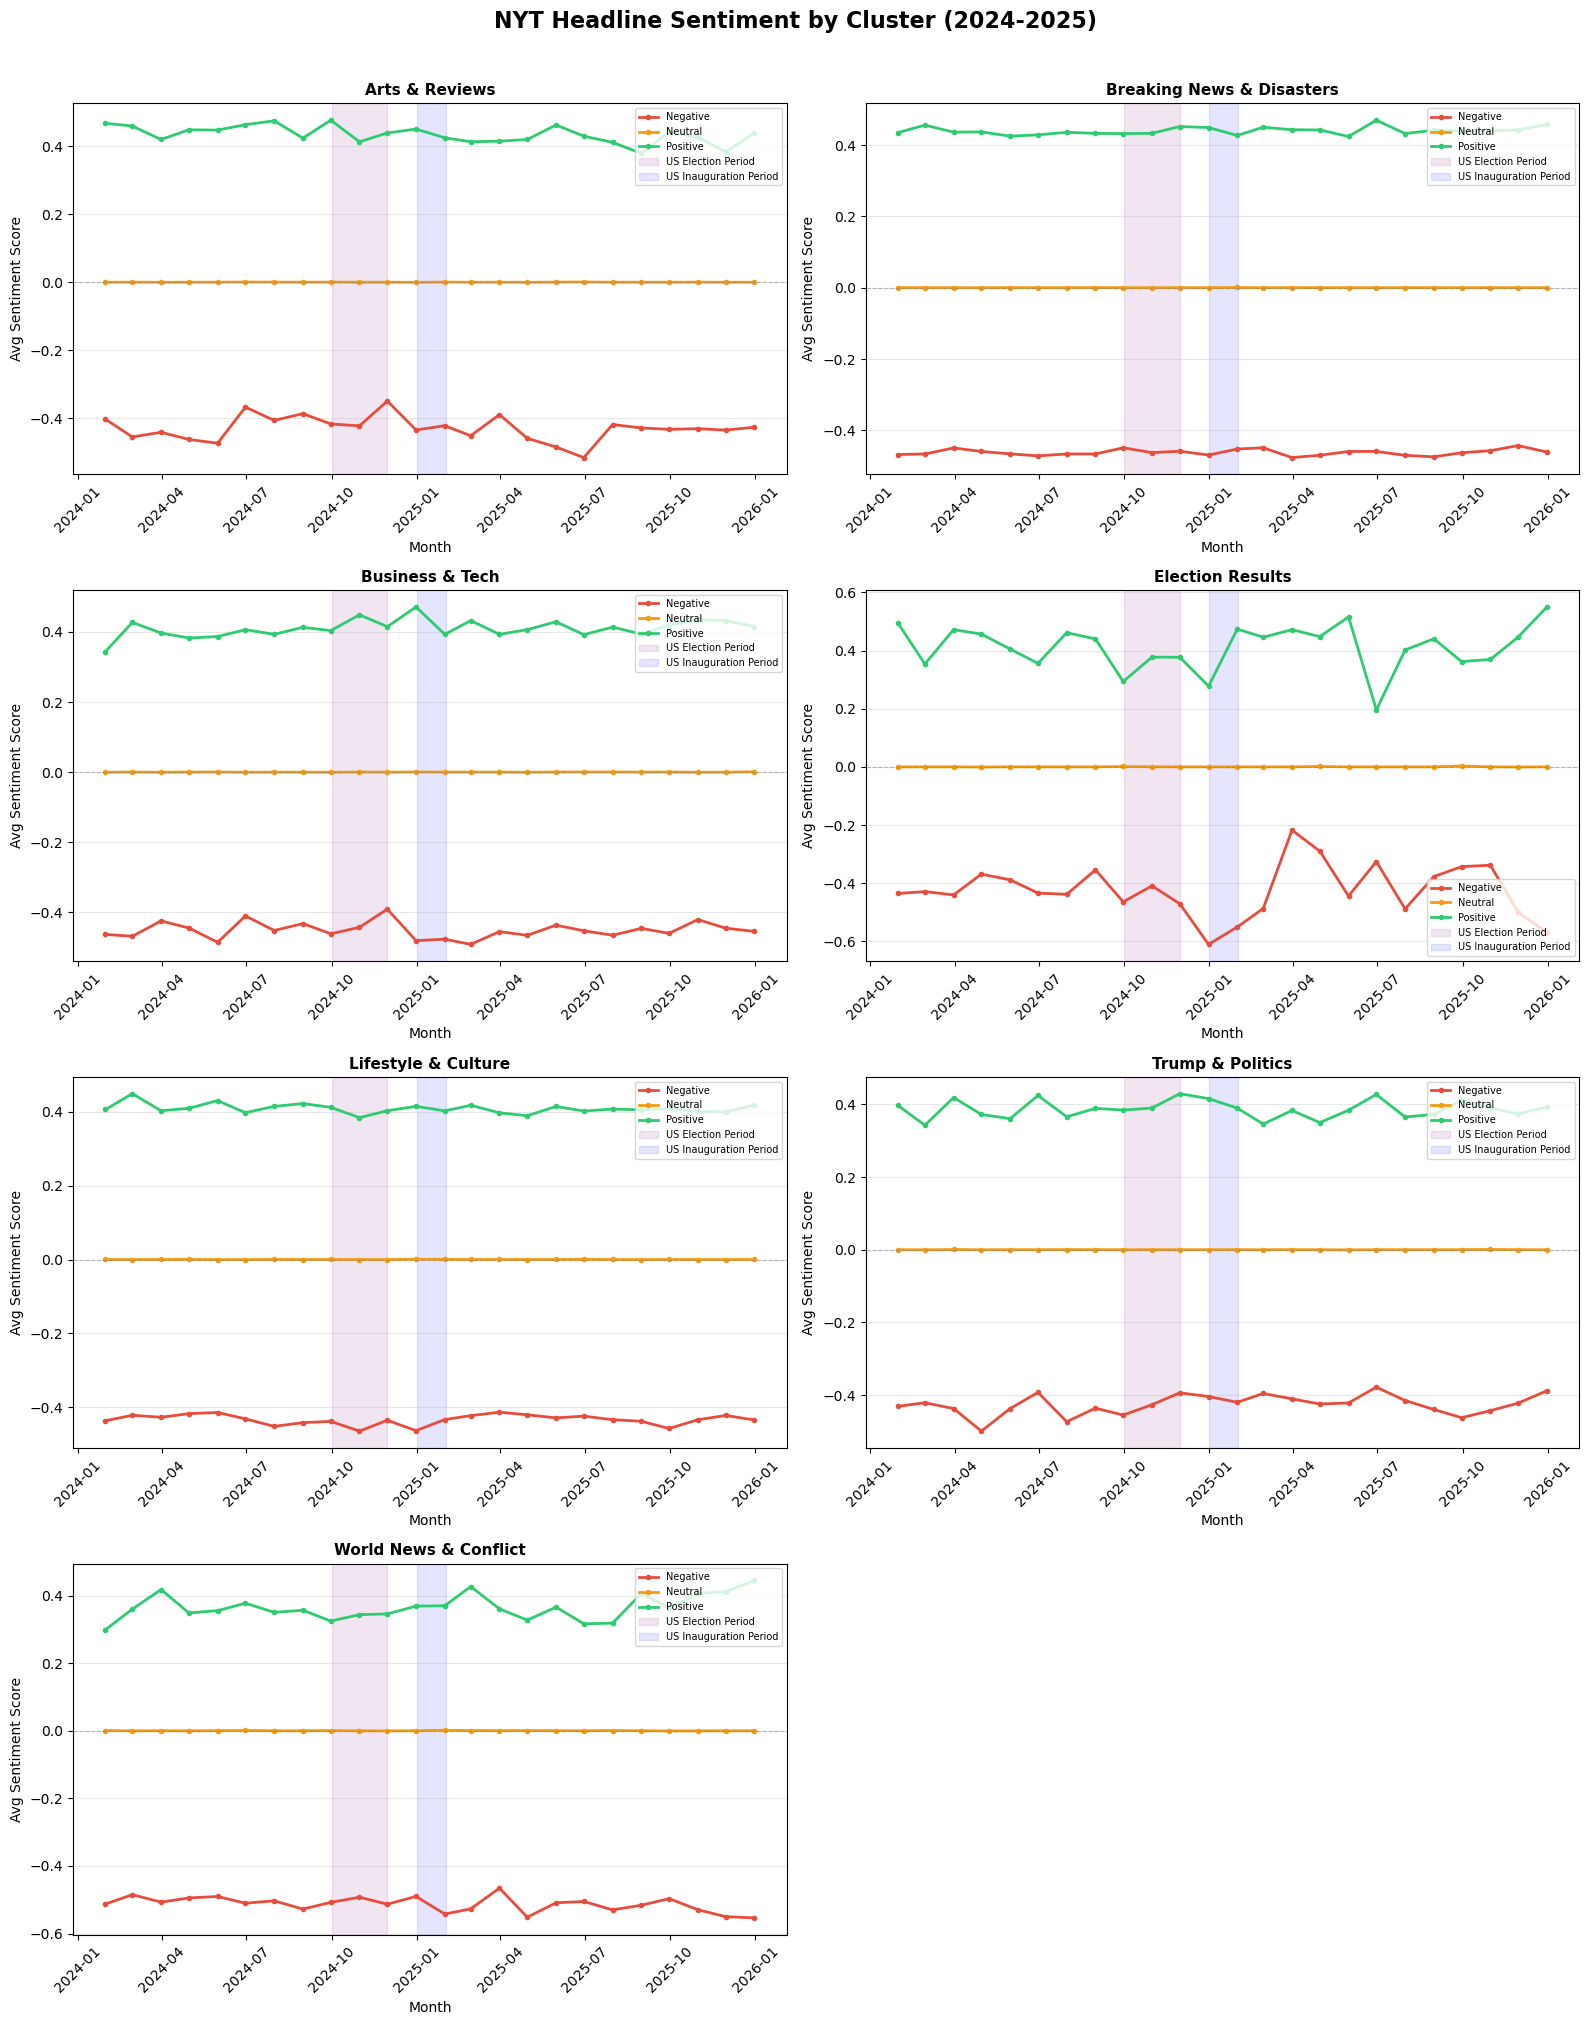

In [76]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

colours = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#f39c12'}

cluster_names = df['cluster_label'].unique()

for i, cluster in enumerate(sorted(cluster_names)):
    ax = axes[i]
    
    cluster_df = df[df['cluster_label'] == cluster].copy()
    cluster_df['date'] = pd.to_datetime(cluster_df['date'])
    
    monthly = cluster_df.groupby([
        pd.Grouper(key='date', freq='ME'), 
        'sentiment_label_headline'
    ])['sentiment_score_headline'].mean().reset_index()
    monthly.columns = ['month_period', 'sentiment_label', 'sentiment_score']
    
    for label, group in monthly.groupby('sentiment_label'):
        ax.plot(group['month_period'], group['sentiment_score'],
                label=label, color=colours.get(label, 'gray'),
                linewidth=2, marker='o', markersize=3)
    
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvspan(pd.Timestamp('2024-10-01'), pd.Timestamp('2024-11-30'),
               alpha=0.1, color='purple', label='US Election Period')
    ax.axvspan(pd.Timestamp('2025-01-01'), pd.Timestamp('2025-02-01'),
               alpha=0.1, color='blue', label='US Inauguration Period')
    
    ax.set_title(cluster, fontsize=11, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Avg Sentiment Score')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7)

axes[7].set_visible(False)

plt.suptitle('NYT Headline Sentiment by Cluster (2024-2025)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sentiment_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()